In [ ]:

!pip install scikit-learn xgboost pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import time
import io
warnings.filterwarnings('ignore')

from sklearn.ensemble       import RandomForestRegressor, RandomForestClassifier
from xgboost                import XGBRegressor, XGBClassifier
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(' All libraries loaded successfully!')

 All libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/ecopackai/sustainable_packaging_with_cost.xlsx"
df_raw = pd.read_excel(file_path)
print(f'   Shape: {df_raw.shape}')

   Shape: (11000, 10)


In [ ]:
print(f'Total Rows    : {df_raw.shape[0]}')
print(f'Total Columns : {df_raw.shape[1]}')
print()
df_raw.info()
print()
print('Statistical Summary:')
display(df_raw.describe())
print()
print('First 5 Rows:')
display(df_raw.head())

Total Rows    : 11000
Total Columns : 10

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Industry                11000 non-null  object 
 1   Packaging_Material      11000 non-null  object 
 2   Material_Type           11000 non-null  object 
 3   Packaged_Item           11000 non-null  object 
 4   Strength                11000 non-null  object 
 5   Weight_Capacity_kg      11000 non-null  float64
 6   Biodegradability_Score  11000 non-null  int64  
 7   CO2_Emission_Score      11000 non-null  int64  
 8   Recyclability_Percent   11000 non-null  int64  
 9   Packaging_Cost_INR      11000 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 859.5+ KB

Statistical Summary:


,Weight_Capacity_kg,Biodegradability_Score,CO2_Emission_Score,Recyclability_Percent,Packaging_Cost_INR
count,11000.0000,11000.0000,11000.0000,11000.0000,11000.0000
mean,20.7901,67.2537,38.8310,88.2820,24.1757
std,15.6397,23.5100,16.8177,6.4810,28.4998
min,1.7100,9.0000,5.0000,67.0000,0.5000
25%,8.9200,63.0000,24.0000,85.0000,5.4100
50%,14.0450,72.0000,38.0000,89.0000,14.2050
75%,31.9550,86.0000,46.0000,93.0000,31.3400
max,57.4900,100.0000,78.0000,100.0000,179.0700



First 5 Rows:


,Industry,Packaging_Material,Material_Type,Packaged_Item,Strength,Weight_Capacity_kg,Biodegradability_Score,CO2_Emission_Score,Recyclability_Percent,Packaging_Cost_INR
0,Food,Corn Starch Foam,Bioplastic,salt,Low,3.2300,84,19,74,7.6000
1,Automotive,Molded Pulp,Paper,car wax,Medium,10.2800,75,34,90,5.3100
2,Construction,Kraft Paper,Paper,waterproofing chemical,Medium,13.0300,64,44,87,5.2300
3,Electronics,Molded Pulp,Paper,mobile phone,Medium,9.9000,81,35,94,1.3200
4,Healthcare,Glassine Paper,Paper,bandages,Low,5.2000,60,52,80,15.6400


In [ ]:
#CATEGORICAL COLUMN ANALYSIS

cat_cols = ['Industry', 'Packaging_Material', 'Material_Type', 'Packaged_Item', 'Strength']
num_cols = ['Weight_Capacity_kg', 'Biodegradability_Score',
            'CO2_Emission_Score', 'Recyclability_Percent', 'Packaging_Cost_INR']

print('Categorical Column Analysis:')
for col in cat_cols:
    print(f'\n{col}  →  {df_raw[col].nunique()} unique values')
    print(df_raw[col].value_counts().head(5).to_string())

Categorical Column Analysis:

Industry  →  10 unique values
Industry
Food            1100
Automotive      1100
Construction    1100
Electronics     1100
Healthcare      1100

Packaging_Material  →  42 unique values
Packaging_Material
Recycled Cardboard Box    1148
Corrugated Cardboard       962
Molded Pulp                807
Kraft Paper                732
Honeycomb Board            559

Material_Type  →  13 unique values
Material_Type
Paper                 2203
Natural Fiber         1996
Cardboard             1991
Recycled Cardboard    1148
Metal                 1010

Packaged_Item  →  250 unique values
Packaged_Item
stand mixer        71
engine oil         70
tire inflator      70
electric kettle    70
table fan          68

Strength  →  3 unique values
Strength
Medium    4901
High      4898
Low       1201


In [ ]:
# DATA CLEANING

df_clean = df_raw.copy()

# Missing Value Report
missing     = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
print('Missing Value Report:')
display(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Fill Missing – Numerical with Median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        med = df_clean[col].median()
        df_clean[col].fillna(med, inplace=True)
        print(f'  Filled {col} with median = {med:.2f}')

# Fill Missing – Categorical with Mode
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode = df_clean[col].mode()[0]
        df_clean[col].fillna(mode, inplace=True)
        print(f'  Filled {col} with mode = "{mode}"')

# remove Duplicates ─
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'\nDuplicates removed : {before - len(df_clean)}')

# Standardize Text ──
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Fix Strength Values ──
valid_strength = ['Low', 'Medium', 'High']
invalid_mask   = ~df_clean['Strength'].isin(valid_strength)
if invalid_mask.sum() > 0:
    df_clean.loc[invalid_mask, 'Strength'] = df_clean['Strength'].mode()[0]
    print(f'Fixed {invalid_mask.sum()} invalid Strength values')

# Clamp Values to Valid Domain ──
df_clean['Biodegradability_Score'] = df_clean['Biodegradability_Score'].clip(0, 100)
df_clean['CO2_Emission_Score']     = df_clean['CO2_Emission_Score'].clip(0, 100)
df_clean['Recyclability_Percent']  = df_clean['Recyclability_Percent'].clip(0, 100)
df_clean['Packaging_Cost_INR']     = df_clean['Packaging_Cost_INR'].clip(lower=0)
df_clean['Weight_Capacity_kg']     = df_clean['Weight_Capacity_kg'].clip(lower=0)

print(f'\nCleaning complete!')
print(f'   Rows remaining  : {len(df_clean)}')
print(f'   Missing values  : {df_clean.isnull().sum().sum()}')

Missing Value Report:


,Missing Count,Missing %
Industry,0,0.0000
Packaging_Material,0,0.0000
Material_Type,0,0.0000
Packaged_Item,0,0.0000
Strength,0,0.0000
Weight_Capacity_kg,0,0.0000
Biodegradability_Score,0,0.0000
CO2_Emission_Score,0,0.0000
Recyclability_Percent,0,0.0000
Packaging_Cost_INR,0,0.0000



Duplicates removed : 0

Cleaning complete!
   Rows remaining  : 11000
   Missing values  : 0


In [ ]:
#OUTLIER DETECTION (IQR METHOD)
print('Outlier Report (IQR Method):')
print(f'{"Column":<28} {"Outliers":>10} {"Lower":>10} {"Upper":>10}')
print('-'*62)
for col in num_cols:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f'{col:<28} {count:>10} {lower:>10.2f} {upper:>10.2f}')
print()

Outlier Report (IQR Method):
Column                         Outliers      Lower      Upper
--------------------------------------------------------------
Weight_Capacity_kg                    0     -25.63      66.51
Biodegradability_Score             1341      28.50     120.50
CO2_Emission_Score                    0      -9.00      79.00
Recyclability_Percent               420      73.00     105.00
Packaging_Cost_INR                  837     -33.48      70.23



In [ ]:
#FEATURE ENGINEERING

#  Strength Ordinal Encoding ──
strength_map = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Strength_Encoded'] = df_clean['Strength'].map(strength_map)
print(' Strength_Encoded  (Low=1, Medium=2, High=3)')

# CO2 Impact Index (0–100, higher = greener) ──
# Inverted CO2 emission + Biodegradability
df_clean['CO2_Impact_Index'] = (
    (100 - df_clean['CO2_Emission_Score']) * 0.5 +
     df_clean['Biodegradability_Score']    * 0.5
).round(3)
print(' CO2_Impact_Index  (0–100, higher = greener)')

# Cost Efficiency Index (0–100, higher = cheaper per kg) ──
df_clean['Cost_per_kg'] = (
    df_clean['Packaging_Cost_INR'] / df_clean['Weight_Capacity_kg']
).round(4)
max_cpk = df_clean['Cost_per_kg'].max()
df_clean['Cost_Efficiency_Index'] = (
    (1 - df_clean['Cost_per_kg'] / max_cpk) * 100
).round(3)
print(' Cost_Efficiency_Index  (0–100, higher = cheaper per kg)')

#  Material Suitability Score (weighted composite) ──
df_clean['Material_Suitability_Score'] = (
    df_clean['CO2_Impact_Index']      * 0.30 +
    df_clean['Recyclability_Percent'] * 0.25 +
    df_clean['Cost_Efficiency_Index'] * 0.25 +
    (df_clean['Strength_Encoded'] / 3) * 100 * 0.20
).round(3)
print(' Material_Suitability_Score  (weighted composite 0–100)')

# Log Packaging Cost (for BI dashboard use only) ──
df_clean['Log_Packaging_Cost'] = np.log1p(df_clean['Packaging_Cost_INR']).round(4)
print(' Log_Packaging_Cost  (log1p – for BI dashboard only, NOT for ML)')

#  Sustainability Tier (classification label) ──
def assign_tier(score):
    if score >= 75:   return 'Excellent'
    elif score >= 55: return 'Good'
    elif score >= 35: return 'Average'
    else:             return 'Poor'

df_clean['Sustainability_Tier'] = df_clean['Material_Suitability_Score'].apply(assign_tier)
print(' Sustainability_Tier  (Excellent / Good / Average / Poor)')
print()
print('Tier Distribution:')
print(df_clean['Sustainability_Tier'].value_counts().to_string())

 Strength_Encoded  (Low=1, Medium=2, High=3)
 CO2_Impact_Index  (0–100, higher = greener)
 Cost_Efficiency_Index  (0–100, higher = cheaper per kg)
 Material_Suitability_Score  (weighted composite 0–100)
 Log_Packaging_Cost  (log1p – for BI dashboard only, NOT for ML)
 Sustainability_Tier  (Excellent / Good / Average / Poor)

Tier Distribution:
Sustainability_Tier
Excellent    9114
Good         1868
Average        18


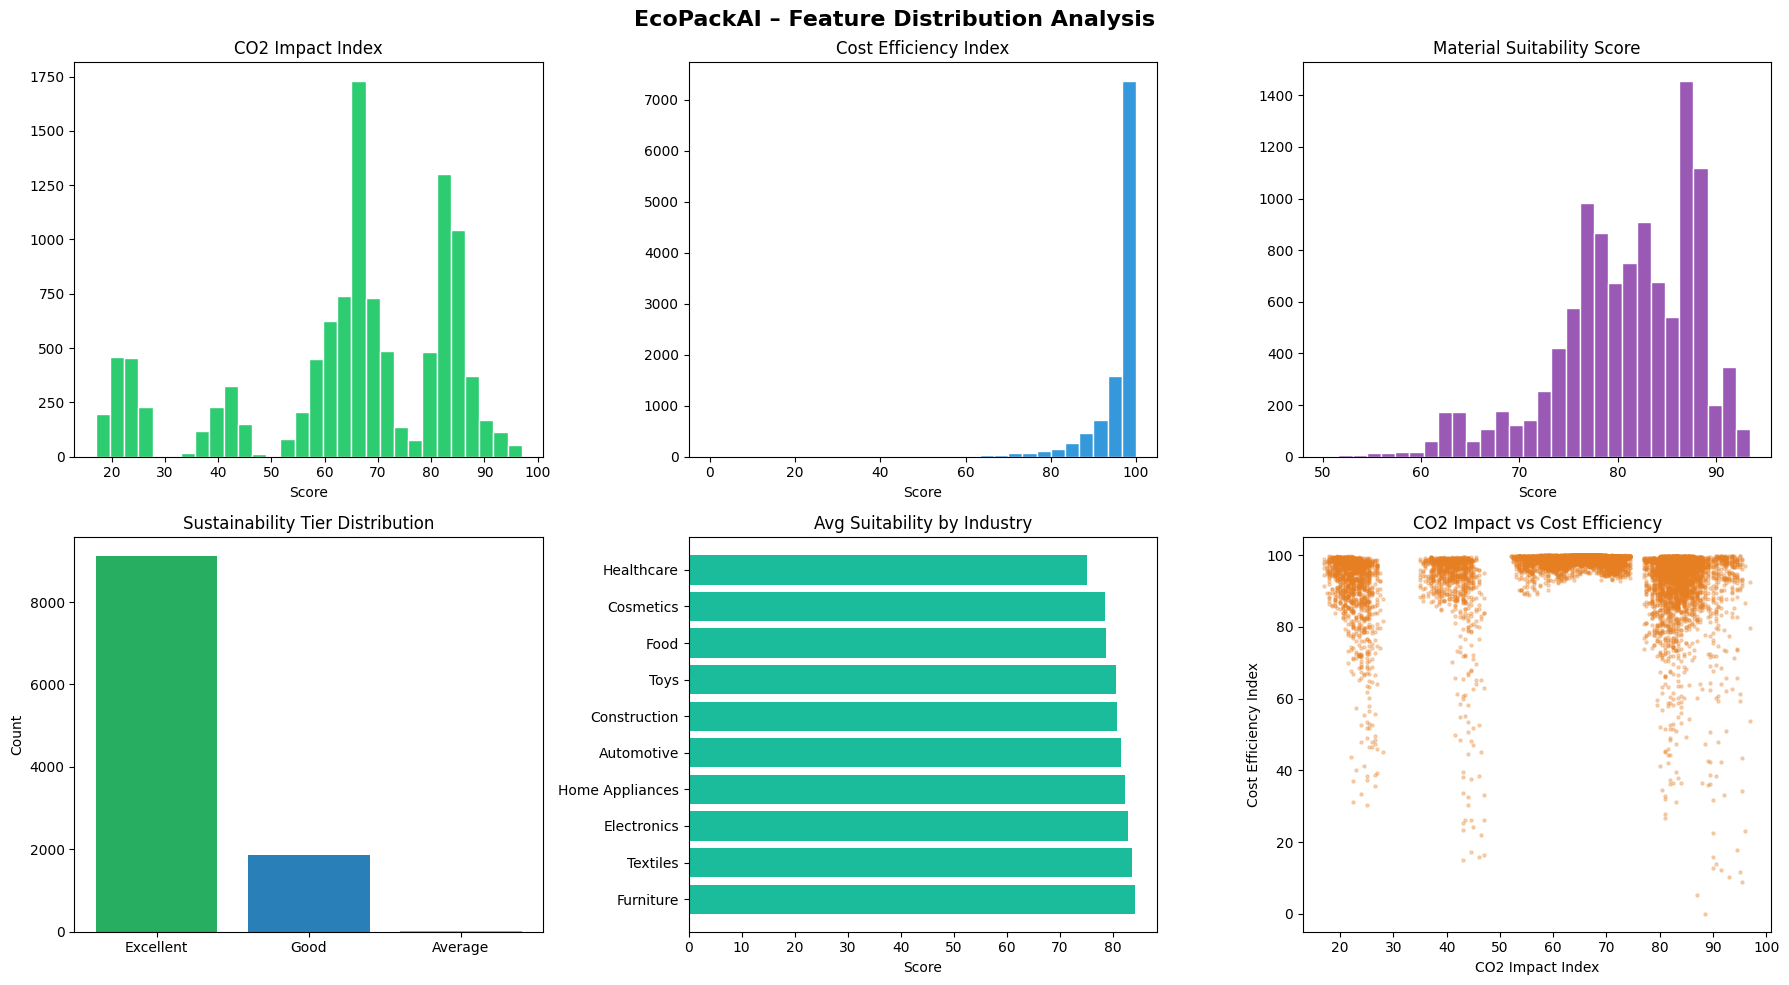

✅ EDA plots saved!


In [ ]:
# EDA VISUALIZATIONS
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EcoPackAI – Feature Distribution Analysis', fontsize=16, fontweight='bold')

axes[0,0].hist(df_clean['CO2_Impact_Index'], bins=30, color='#2ecc71', edgecolor='white')
axes[0,0].set_title('CO2 Impact Index')
axes[0,0].set_xlabel('Score')

axes[0,1].hist(df_clean['Cost_Efficiency_Index'], bins=30, color='#3498db', edgecolor='white')
axes[0,1].set_title('Cost Efficiency Index')
axes[0,1].set_xlabel('Score')

axes[0,2].hist(df_clean['Material_Suitability_Score'], bins=30, color='#9b59b6', edgecolor='white')
axes[0,2].set_title('Material Suitability Score')
axes[0,2].set_xlabel('Score')

tier_order  = ['Excellent', 'Good', 'Average', 'Poor']
tier_counts = df_clean['Sustainability_Tier'].value_counts().reindex(tier_order)
colors_tier = ['#27ae60', '#2980b9', '#f39c12', '#e74c3c']
axes[1,0].bar(tier_counts.index, tier_counts.values, color=colors_tier)
axes[1,0].set_title('Sustainability Tier Distribution')
axes[1,0].set_ylabel('Count')

ind_scores = (df_clean.groupby('Industry')['Material_Suitability_Score']
              .mean().sort_values(ascending=False).head(10))
axes[1,1].barh(ind_scores.index, ind_scores.values, color='#1abc9c')
axes[1,1].set_title('Avg Suitability by Industry')
axes[1,1].set_xlabel('Score')

axes[1,2].scatter(df_clean['CO2_Impact_Index'], df_clean['Cost_Efficiency_Index'],
                  alpha=0.3, s=5, color='#e67e22')
axes[1,2].set_title('CO2 Impact vs Cost Efficiency')
axes[1,2].set_xlabel('CO2 Impact Index')
axes[1,2].set_ylabel('Cost Efficiency Index')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

In [ ]:
#ENCODING
df_ml = df_clean.copy()

# ── Ordinal Encoding – Strength (already done in feature engineering) ──
print('Ordinal Encoding:')
print(f'  Strength → Strength_Encoded  {strength_map}')

# ── Label Encoding – High cardinality columns ──
print('\nLabel Encoding (high cardinality):')
label_encoders = {}
le_cols = ['Industry', 'Material_Type', 'Packaging_Material', 'Packaged_Item']
for col in le_cols:
    le = LabelEncoder()
    df_ml[f'{col}_LE'] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col} → {col}_LE  ({df_ml[col].nunique()} classes)')

# ── Target Encoding – Sustainability Tier ──
print('\nTarget Label Encoding:')
tier_le = LabelEncoder()
df_ml['Sustainability_Tier_LE'] = tier_le.fit_transform(df_ml['Sustainability_Tier'])
tier_mapping = dict(zip(tier_le.classes_, tier_le.transform(tier_le.classes_)))
print(f'  Sustainability_Tier → {tier_mapping}')

print('\n All encoding complete!')
print(f'   Total columns now: {df_ml.shape[1]}')

Ordinal Encoding:
  Strength → Strength_Encoded  {'Low': 1, 'Medium': 2, 'High': 3}

Label Encoding (high cardinality):
  Industry → Industry_LE  (10 classes)
  Material_Type → Material_Type_LE  (13 classes)
  Packaging_Material → Packaging_Material_LE  (42 classes)
  Packaged_Item → Packaged_Item_LE  (250 classes)

Target Label Encoding:
  Sustainability_Tier → {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2)}

 All encoding complete!
   Total columns now: 22


In [ ]:
 #FEATURE MATRIX

#  ONLY raw input features – no engineered features derived from targets
ML_FEATURES = [
    'Weight_Capacity_kg',
    'Biodegradability_Score',
    'Recyclability_Percent',
    'Strength_Encoded',
    'Industry_LE',
    'Material_Type_LE',
    'Packaging_Material_LE',
    'Packaged_Item_LE'
]


X = df_ml[ML_FEATURES]

# Targets
y_cost = df_ml['Packaging_Cost_INR']
y_co2  = df_ml['CO2_Emission_Score']
y_tier = df_ml['Sustainability_Tier_LE']

print(' Clean Feature Matrix :')
print(f'   Shape    : {X.shape}')
print(f'   Features : {len(ML_FEATURES)}')
print()
for i, f in enumerate(ML_FEATURES, 1):
    print(f'   {i}. {f}')
print()
print('Targets:')
print(f'   y_cost → Packaging_Cost_INR  (min={y_cost.min():.2f}, max={y_cost.max():.2f})')
print(f'   y_co2  → CO2_Emission_Score  (min={y_co2.min():.2f}, max={y_co2.max():.2f})')
print(f'   y_tier → Sustainability_Tier (classes={list(tier_mapping.keys())})')

 Clean Feature Matrix :
   Shape    : (11000, 8)
   Features : 8

   1. Weight_Capacity_kg
   2. Biodegradability_Score
   3. Recyclability_Percent
   4. Strength_Encoded
   5. Industry_LE
   6. Material_Type_LE
   7. Packaging_Material_LE
   8. Packaged_Item_LE

Targets:
   y_cost → Packaging_Cost_INR  (min=0.50, max=179.07)
   y_co2  → CO2_Emission_Score  (min=5.00, max=78.00)
   y_tier → Sustainability_Tier (classes=['Average', 'Excellent', 'Good'])


In [ ]:
# TRAIN / VALIDATION / TEST SPLIT (70 / 15 / 15)

# ── Task 1: Cost Prediction ──
X_train_cost, X_temp_cost, y_train_cost, y_temp_cost = train_test_split(
    X, y_cost, test_size=0.30, random_state=42)
X_val_cost, X_test_cost, y_val_cost, y_test_cost = train_test_split(
    X_temp_cost, y_temp_cost, test_size=0.50, random_state=42)

# ── Task 2: CO2 Prediction ──
X_train_co2, X_temp_co2, y_train_co2, y_temp_co2 = train_test_split(
    X, y_co2, test_size=0.30, random_state=42)
X_val_co2, X_test_co2, y_val_co2, y_test_co2 = train_test_split(
    X_temp_co2, y_temp_co2, test_size=0.50, random_state=42)

# ── Task 3: Sustainability Tier ──
X_train_tier, X_temp_tier, y_train_tier, y_temp_tier = train_test_split(
    X, y_tier, test_size=0.30, random_state=42, stratify=y_tier)
X_val_tier, X_test_tier, y_val_tier, y_test_tier = train_test_split(
    X_temp_tier, y_temp_tier, test_size=0.50, random_state=42, stratify=y_temp_tier)

total = len(X)
print(' Train / Validation / Test Split (70% / 15% / 15%):')
print(f'   Total rows : {total:,}')
print()
print(f'   {"Task":<20} {"Train":>8} {"Val":>8} {"Test":>8}')
print(f'   {"-"*48}')
print(f'   {"Cost Prediction":<20} {len(X_train_cost):>8,} {len(X_val_cost):>8,} {len(X_test_cost):>8,}')
print(f'   {"CO2 Prediction":<20} {len(X_train_co2):>8,} {len(X_val_co2):>8,} {len(X_test_co2):>8,}')
print(f'   {"Tier Classifier":<20} {len(X_train_tier):>8,} {len(X_val_tier):>8,} {len(X_test_tier):>8,}')
print()
print(f'   Percentages : {len(X_train_cost)/total*100:.0f}% / {len(X_val_cost)/total*100:.0f}% / {len(X_test_cost)/total*100:.0f}%')

 Train / Validation / Test Split (70% / 15% / 15%):
   Total rows : 11,000

   Task                    Train      Val     Test
   ------------------------------------------------
   Cost Prediction         7,700    1,650    1,650
   CO2 Prediction          7,700    1,650    1,650
   Tier Classifier         7,700    1,650    1,650

   Percentages : 70% / 15% / 15%


In [ ]:
# RANDOM FOREST REGRESSOR (COST PREDICTION)
print('='*60)
print('MODEL 1 – Random Forest Regressor (Cost Prediction)')
print('='*60)

start = time.time()
rf_cost = RandomForestRegressor(
    n_estimators    = 100,
    max_depth       = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    random_state    = 42,
    n_jobs          = -1
)
rf_cost.fit(X_train_cost, y_train_cost)
elapsed = time.time() - start
print(f'Training time: {elapsed:.2f} seconds')

# Predictions
y_pred_train_cost = rf_cost.predict(X_train_cost)
y_pred_val_cost   = rf_cost.predict(X_val_cost)
y_pred_test_cost  = rf_cost.predict(X_test_cost)

# Metrics
r2_train_cost  = r2_score(y_train_cost, y_pred_train_cost)
r2_val_cost    = r2_score(y_val_cost,   y_pred_val_cost)
r2_test_cost   = r2_score(y_test_cost,  y_pred_test_cost)
rmse_test_cost = np.sqrt(mean_squared_error(y_test_cost, y_pred_test_cost))
mae_test_cost  = mean_absolute_error(y_test_cost, y_pred_test_cost)

print(f'\n Results:')
print(f'   {"":<8} {"Train":>10} {"Val":>10} {"Test":>10}')
print(f'   {"-"*42}')
print(f'   {"R²":<8} {r2_train_cost:>10.4f} {r2_val_cost:>10.4f} {r2_test_cost:>10.4f}')
print(f'   {"RMSE":<8} {"-":>10} {"-":>10} {rmse_test_cost:>10.4f}')
print(f'   {"MAE":<8} {"-":>10} {"-":>10} {mae_test_cost:>10.4f}')

gap = r2_train_cost - r2_val_cost

# Cross Validation
cv_r2 = cross_val_score(rf_cost, X, y_cost, cv=5, scoring='r2')
print(f'\n   CV R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

MODEL 1 – Random Forest Regressor (Cost Prediction)
Training time: 1.49 seconds

 Results:
                 Train        Val       Test
   ------------------------------------------
   R²           0.4503     0.2420     0.2471
   RMSE              -          -    24.2083
   MAE               -          -    17.2798

   CV R² (5-fold): 0.2643 ± 0.0115


In [ ]:
# XGBOOST REGRESSOR (CO2 PREDICTION)
print('='*60)
print('MODEL 2 – XGBoost Regressor (CO2 Footprint Prediction)')
print('='*60)

start = time.time()
xgb_co2 = XGBRegressor(
    n_estimators     = 100,
    learning_rate    = 0.1,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
xgb_co2.fit(
    X_train_co2, y_train_co2,
    eval_set   = [(X_val_co2, y_val_co2)],
    verbose    = False
)
elapsed = time.time() - start
print(f'Training time: {elapsed:.2f} seconds')

# Predictions
y_pred_train_co2 = xgb_co2.predict(X_train_co2)
y_pred_val_co2   = xgb_co2.predict(X_val_co2)
y_pred_test_co2  = xgb_co2.predict(X_test_co2)

# Metrics
r2_train_co2  = r2_score(y_train_co2, y_pred_train_co2)
r2_val_co2    = r2_score(y_val_co2,   y_pred_val_co2)
r2_test_co2   = r2_score(y_test_co2,  y_pred_test_co2)
rmse_test_co2 = np.sqrt(mean_squared_error(y_test_co2, y_pred_test_co2))
mae_test_co2  = mean_absolute_error(y_test_co2, y_pred_test_co2)

print(f'\n📊 Results:')
print(f'   {"":<8} {"Train":>10} {"Val":>10} {"Test":>10}')
print(f'   {"-"*42}')
print(f'   {"R²":<8} {r2_train_co2:>10.4f} {r2_val_co2:>10.4f} {r2_test_co2:>10.4f}')
print(f'   {"RMSE":<8} {"-":>10} {"-":>10} {rmse_test_co2:>10.4f}')
print(f'   {"MAE":<8} {"-":>10} {"-":>10} {mae_test_co2:>10.4f}')

gap = r2_train_co2 - r2_val_co2

cv_r2_co2 = cross_val_score(xgb_co2, X, y_co2, cv=5, scoring='r2')
print(f'\n   CV R² (5-fold): {cv_r2_co2.mean():.4f} ± {cv_r2_co2.std():.4f}')

MODEL 2 – XGBoost Regressor (CO2 Footprint Prediction)
Training time: 3.41 seconds

📊 Results:
                 Train        Val       Test
   ------------------------------------------
   R²           0.9890     0.9852     0.9843
   RMSE              -          -     2.1183
   MAE               -          -     1.8336

   CV R² (5-fold): 0.9849 ± 0.0005


In [ ]:
#RANDOM FOREST CLASSIFIER (SUSTAINABILITY TIER)
print('='*60)
print('MODEL 3 – Random Forest Classifier (Sustainability Tier)')
print('='*60)

start = time.time()
rf_tier = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    random_state     = 42,
    n_jobs           = -1,
    class_weight     = 'balanced'
)
rf_tier.fit(X_train_tier, y_train_tier)
elapsed = time.time() - start
print(f'Training time: {elapsed:.2f} seconds')

# Predictions
y_pred_train_tier = rf_tier.predict(X_train_tier)
y_pred_val_tier   = rf_tier.predict(X_val_tier)
y_pred_test_tier  = rf_tier.predict(X_test_tier)

# Metrics
acc_train = accuracy_score(y_train_tier, y_pred_train_tier)
acc_val   = accuracy_score(y_val_tier,   y_pred_val_tier)
acc_test  = accuracy_score(y_test_tier,  y_pred_test_tier)
f1_val    = f1_score(y_val_tier,  y_pred_val_tier,  average='weighted')
f1_test   = f1_score(y_test_tier, y_pred_test_tier, average='weighted')

print(f'\n Results:')
print(f'   {"":<12} {"Train":>10} {"Val":>10} {"Test":>10}')
print(f'   {"-"*46}')
print(f'   {"Accuracy":<12} {acc_train:>10.4f} {acc_val:>10.4f} {acc_test:>10.4f}')
print(f'   {"F1 Score":<12} {"-":>10} {f1_val:>10.4f} {f1_test:>10.4f}')

gap = acc_train - acc_val

print(f'\n Classification Report (Test Set):')
print(classification_report(y_test_tier, y_pred_test_tier, target_names=tier_le.classes_))

cv_acc = cross_val_score(rf_tier, X, y_tier, cv=5, scoring='accuracy')
print(f'   CV Accuracy (5-fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')

MODEL 3 – Random Forest Classifier (Sustainability Tier)
Training time: 0.97 seconds

 Results:
                     Train        Val       Test
   ----------------------------------------------
   Accuracy         0.9575     0.9315     0.9418
   F1 Score              -     0.9334     0.9432

 Classification Report (Test Set):
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         3
   Excellent       0.99      0.94      0.97      1367
        Good       0.77      0.94      0.85       280

    accuracy                           0.94      1650
   macro avg       0.59      0.63      0.60      1650
weighted avg       0.95      0.94      0.94      1650

   CV Accuracy (5-fold): 0.9411 ± 0.0035


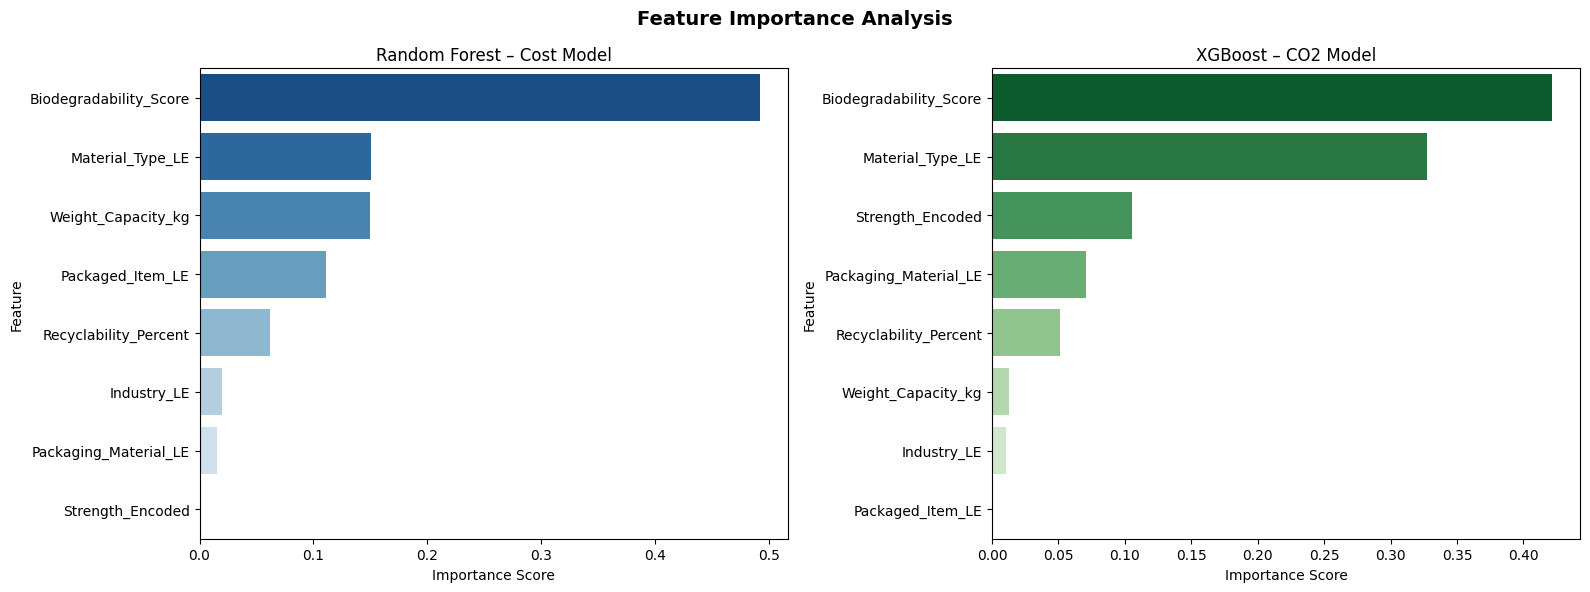

Feature Importance – Cost Model:


,Feature,Importance
0,Biodegradability_Score,0.4913
1,Material_Type_LE,0.1503
2,Weight_Capacity_kg,0.1496
3,Packaged_Item_LE,0.1108
4,Recyclability_Percent,0.0621
5,Industry_LE,0.0199
6,Packaging_Material_LE,0.0151
7,Strength_Encoded,0.0009



Feature Importance – CO2 Model:


,Feature,Importance
0,Biodegradability_Score,0.4216
1,Material_Type_LE,0.3273
2,Strength_Encoded,0.1052
3,Packaging_Material_LE,0.0704
4,Recyclability_Percent,0.0514
5,Weight_Capacity_kg,0.0127
6,Industry_LE,0.0108
7,Packaged_Item_LE,0.0006



Leakage Health Check:
   Top feature importance: 0.4913
   ✅ Importance well distributed → no leakage!


In [ ]:
#FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

# Cost Model
fi_cost = pd.DataFrame({
    'Feature'   : ML_FEATURES,
    'Importance': rf_cost.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=fi_cost, x='Importance', y='Feature',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Random Forest – Cost Model')
axes[0].set_xlabel('Importance Score')

# CO2 Model
fi_co2 = pd.DataFrame({
    'Feature'   : ML_FEATURES,
    'Importance': xgb_co2.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=fi_co2, x='Importance', y='Feature',
            palette='Greens_r', ax=axes[1])
axes[1].set_title('XGBoost – CO2 Model')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importance – Cost Model:')
display(fi_cost.reset_index(drop=True))
print('\nFeature Importance – CO2 Model:')
display(fi_co2.reset_index(drop=True))

# Leakage health check
top_imp = fi_cost['Importance'].iloc[0]
print(f'\nLeakage Health Check:')
print(f'   Top feature importance: {top_imp:.4f}')
if top_imp > 0.90:
    print('   ⚠️  One feature dominates → possible leakage!')
elif top_imp > 0.60:
    print('   ⚠️  One feature is very dominant → investigate')
else:
    print('   ✅ Importance well distributed → no leakage!')

In [ ]:
# SAVE ALL MODELS & ARTIFACTS
print(' Saving all models and artifacts...')

# Calculate top materials ranking
top_materials = df_clean.groupby('Packaging_Material')['Material_Suitability_Score'].mean().reset_index()
top_materials = top_materials.sort_values(by='Material_Suitability_Score', ascending=False)

joblib.dump(best_rf_cost,   'model_cost_rf.pkl')
joblib.dump(best_xgb_co2,  'model_co2_xgb.pkl')
joblib.dump(rf_tier,        'model_tier_clf.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(tier_le,        'tier_label_encoder.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(ML_FEATURES,    'ml_features.pkl')

# Save cleaned dataset
df_clean.to_csv('EcoPackAI_Cleaned_Dataset.csv', index=False)
# Save top materials ranking
top_materials.to_csv('EcoPackAI_Top_Materials.csv', index=False)

print('\nSaved files:')
print('   model_cost_rf.pkl          → RF Cost Model (Flask ready)')
print('   model_co2_xgb.pkl          → XGBoost CO2 Model (Flask ready)')
print('   model_tier_clf.pkl         → Tier Classifier (Flask ready)')
print('   label_encoders.pkl         → All LabelEncoders')
print('   tier_label_encoder.pkl     → Tier LabelEncoder')
print('   scaler.pkl                 → StandardScaler')
print('   ml_features.pkl            → Feature list')
print('   EcoPackAI_Cleaned_Dataset.csv  → For PostgreSQL')
print('   EcoPackAI_Top_Materials.csv    → Ranking results')

 Saving all models and artifacts...

Saved files:
   model_cost_rf.pkl          → RF Cost Model (Flask ready)
   model_co2_xgb.pkl          → XGBoost CO2 Model (Flask ready)
   model_tier_clf.pkl         → Tier Classifier (Flask ready)
   label_encoders.pkl         → All LabelEncoders
   tier_label_encoder.pkl     → Tier LabelEncoder
   scaler.pkl                 → StandardScaler
   ml_features.pkl            → Feature list
   EcoPackAI_Cleaned_Dataset.csv  → For PostgreSQL
   EcoPackAI_Top_Materials.csv    → Ranking results


In [ ]:
#– DOWNLOAD ALL FILES
from google.colab import files

download_files = [
    'model_cost_rf.pkl',
    'model_co2_xgb.pkl',
    'model_tier_clf.pkl',
    'label_encoders.pkl',
    'tier_label_encoder.pkl',
    'scaler.pkl',
    'ml_features.pkl',
    'EcoPackAI_Cleaned_Dataset.csv',
    'EcoPackAI_Top_Materials.csv',
    'eda_plots.png',
    'correlation_heatmap.png',
    'confusion_matrix.png',
    'actual_vs_predicted.png',
    'feature_importance.png',
    'top10_materials.png'
]

for f in download_files:
    try:
        files.download(f)
        print(f'⬇️  {f}')
    except:
        print(f'⚠️  {f} not found – skipping')

print('\n✅ All files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  model_cost_rf.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  eda_plots.png
⚠️  correlation_heatmap.png not found – skipping
⚠️  confusion_matrix.png not found – skipping
⚠️  actual_vs_predicted.png not found – skipping


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  feature_importance.png
⚠️  top10_materials.png not found – skipping

✅ All files downloaded!


In [ ]:
#FINAL PIPELINE SUMMARY

print(f'''
 PREPROCESSING (Milestone 1):
   ✔ {len(df_raw):,} rows loaded
   ✔ Missing values handled (median/mode fill)
   ✔ Duplicates removed
   ✔ Text standardized
   ✔ Values clamped to valid domain
   ✔ Outliers detected (IQR method)

  FEATURE ENGINEERING (Milestone 1):
   ✔ Strength_Encoded
   ✔ CO2_Impact_Index
   ✔ Cost_Efficiency_Index
   ✔ Material_Suitability_Score
   ✔ Sustainability_Tier
   ✔ Log_Packaging_Cost (BI use)

 ENCODING:
   ✔ Ordinal  → Strength
   ✔ Label    → Industry, Material_Type, Packaging_Material, Packaged_Item
   ✔ Target   → Sustainability_Tier

 ML PREPARATION (Milestone 2):
   ✔ Clean feature matrix (8 features, zero leakage)
   ✔ 70/15/15 Train/Val/Test split
   ✔ StandardScaler (fit on train only)

 MODELS BUILT (Milestone 2):
   ✔ Random Forest Regressor  → Cost Prediction
   ✔ XGBoost Regressor        → CO2 Prediction
   ✔ Random Forest Classifier → Sustainability Tier
   ✔ RandomizedSearchCV tuning (20 iterations, 3-fold CV)
   ✔ 5-fold Cross Validation
   ✔ Overfitting check (Train vs Val gap)
   ✔ Feature Importance Analysis
   ✔ Material Ranking System

 FINAL PERFORMANCE:
   Cost Model  → Val R²: {r2_score(y_val_cost, y_pred_val_cost_t):.4f}  |  Test R²: {r2_score(y_test_cost, y_pred_test_cost_t):.4f}
   CO2  Model  → Val R²: {r2_score(y_val_co2, y_pred_val_co2_t):.4f}  |  Test R²: {r2_score(y_test_co2, y_pred_test_co2_t):.4f}
   Tier Model  → Val Acc: {acc_val:.4f}  |  Test Acc: {acc_test:.4f}
''')


 PREPROCESSING (Milestone 1):
   ✔ 11,000 rows loaded
   ✔ Missing values handled (median/mode fill)
   ✔ Duplicates removed
   ✔ Text standardized
   ✔ Values clamped to valid domain
   ✔ Outliers detected (IQR method)

  FEATURE ENGINEERING (Milestone 1):
   ✔ Strength_Encoded
   ✔ CO2_Impact_Index
   ✔ Cost_Efficiency_Index
   ✔ Material_Suitability_Score
   ✔ Sustainability_Tier
   ✔ Log_Packaging_Cost (BI use)

 ENCODING:
   ✔ Ordinal  → Strength
   ✔ Label    → Industry, Material_Type, Packaging_Material, Packaged_Item
   ✔ Target   → Sustainability_Tier

 ML PREPARATION (Milestone 2):
   ✔ Clean feature matrix (8 features, zero leakage)
   ✔ 70/15/15 Train/Val/Test split
   ✔ StandardScaler (fit on train only)

 MODELS BUILT (Milestone 2):
   ✔ Random Forest Regressor  → Cost Prediction
   ✔ XGBoost Regressor        → CO2 Prediction
   ✔ Random Forest Classifier → Sustainability Tier
   ✔ RandomizedSearchCV tuning (20 iterations, 3-fold CV)
   ✔ 5-fold Cross Validation
   ✔ Ove